In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [33]:
df = pd.read_csv('../data/spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [34]:
df = df[['v1', 'v2']]
df.columns = ['label', 'text']
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [36]:
df.shape

(5572, 2)

In [37]:
df.describe()

,label,text
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [38]:
df.isnull().sum()

label    0
text     0
dtype: int64

**Class Destribution**

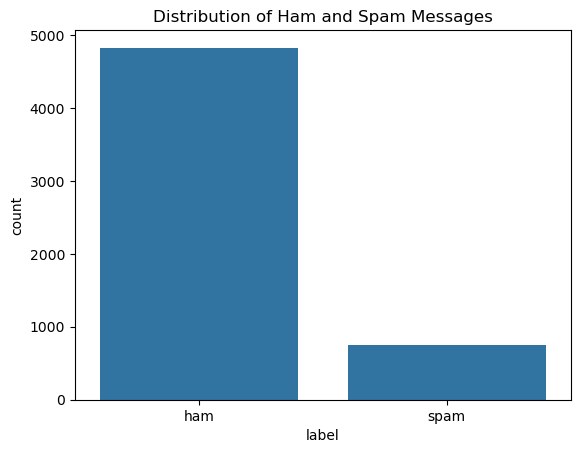

In [39]:
sns.countplot(x='label', data=df)
plt.title('Distribution of Ham and Spam Messages')
plt.show()

**Message Length Analysis**

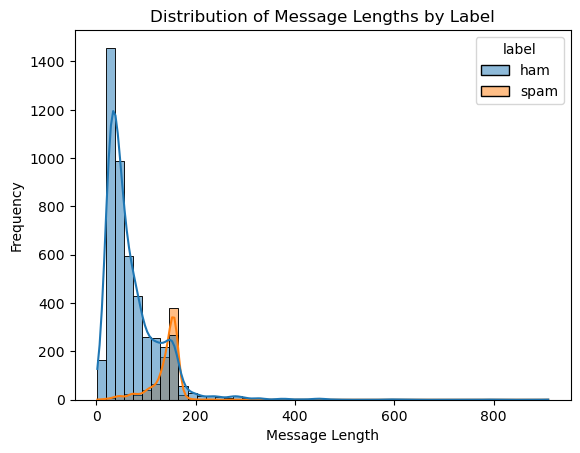

In [40]:
df['length'] = df['text'].apply(len)
sns.histplot(data=df, x='length', hue='label', bins=50, kde=True)
plt.title('Distribution of Message Lengths by Label')
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.show()  

(-0.5, 799.5, 399.5, -0.5)

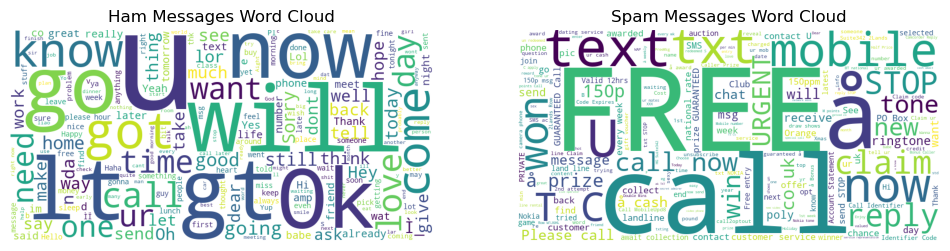

In [41]:
from wordcloud import WordCloud
ham_words = ' '.join(df[df['label'] == 'ham']['text'])
spam_words = ' '.join(df[df['label'] == 'spam']['text'])
ham_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(ham_words)
spam_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(spam_words)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(WordCloud.to_image(ham_wordcloud))
plt.title('Ham Messages Word Cloud')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(WordCloud.to_image(spam_wordcloud))
plt.title('Spam Messages Word Cloud')
plt.axis('off')

**Text Preprocessing**

In [42]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stopwords.words('english')]
    return ' '.join(words)

df['cleaned_text'] = df['text'].apply(clean_text)

**Label Encoding**

In [43]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

**Train Test Split**

In [44]:
X_train, X_test, y_train, y_test = train_test_split(df['cleaned_text'], df['label'], test_size=0.2, random_state=42)

**Text Tokenization**

In [45]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

**Padding**

In [46]:
max_len = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

**CNN Model**

In [47]:
model = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=max_len), 
    Conv1D(128, 5, activation='relu'), 
    GlobalMaxPooling1D(), 
    Dense(64, activation='relu'), 
    Dropout(0.5), 
    Dense(1, activation='sigmoid')
])

c:\Users\ASUS\anaconda3\envs\ds\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


**Compile Model**

In [48]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

**Train Model**

In [49]:
history = model.fit(X_train_pad, y_train, epochs=5, batch_size=32, validation_split=0.1)

Epoch 1/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9030 - loss: 0.2854 - val_accuracy: 0.9641 - val_loss: 0.1571
Epoch 2/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9853 - loss: 0.0498 - val_accuracy: 0.9731 - val_loss: 0.1311
Epoch 3/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9973 - loss: 0.0126 - val_accuracy: 0.9709 - val_loss: 0.1621
Epoch 4/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9990 - loss: 0.0052 - val_accuracy: 0.9731 - val_loss: 0.1554
Epoch 5/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9993 - loss: 0.0038 - val_accuracy: 0.9709 - val_loss: 0.1936


**Model Evaluation**

In [50]:
model.evaluate(X_test_pad, y_test)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9839 - loss: 0.1017 


[0.10170083492994308, 0.9838564991950989]

**Predictions**

In [51]:
y_pred = (model.predict(X_test_pad) > 0.5).astype("int32")

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


**Classification Report**

In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.99      0.89      0.94       150

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



**Confusion Metrix**

Text(0.5, 1.0, 'Confusion Matrix for CNN Model')

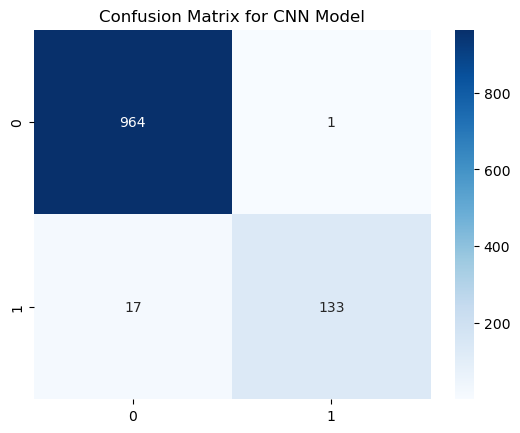

In [53]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for CNN Model')

**Training Visualization**

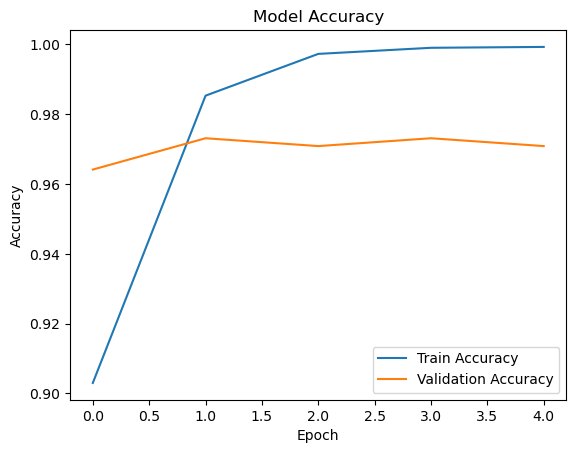

In [54]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


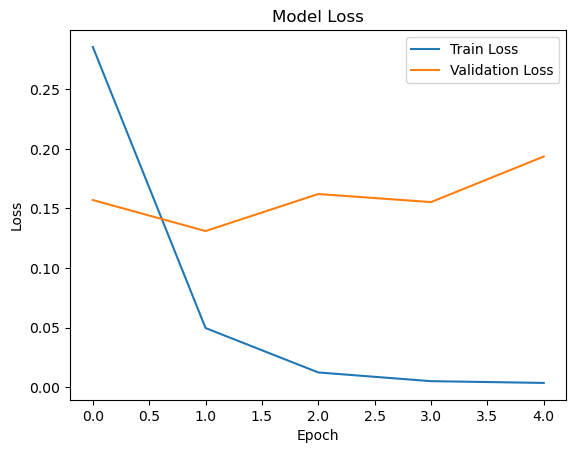

In [55]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [57]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_tfidf, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [58]:
y_pred_lr = lr.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       965
           1       0.96      0.68      0.80       150

    accuracy                           0.95      1115
   macro avg       0.96      0.84      0.89      1115
weighted avg       0.95      0.95      0.95      1115



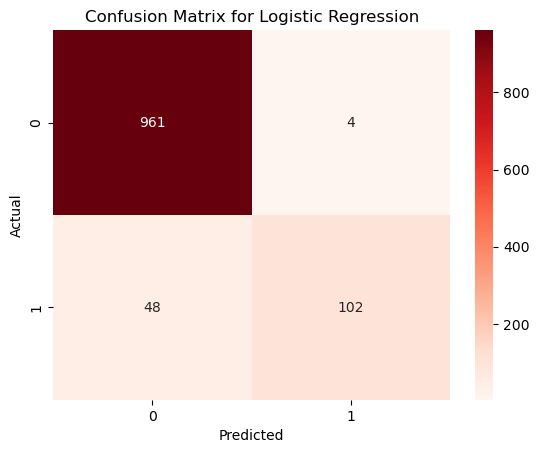

In [59]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


**Model Comparison**

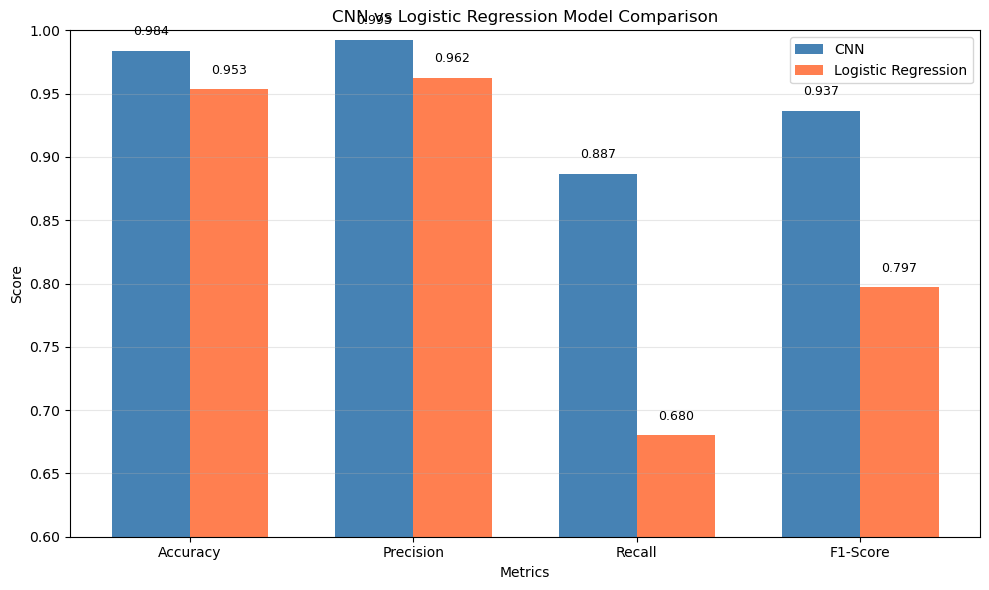

In [60]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# CNN metrics
cnn_accuracy = accuracy_score(y_test, y_pred)
cnn_precision = precision_score(y_test, y_pred)
cnn_recall = recall_score(y_test, y_pred)
cnn_f1 = f1_score(y_test, y_pred)

# Logistic Regression metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

# Comparison data
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
cnn_scores = [cnn_accuracy, cnn_precision, cnn_recall, cnn_f1]
lr_scores = [lr_accuracy, lr_precision, lr_recall, lr_f1]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, cnn_scores, width, label='CNN', color='steelblue')
plt.bar(x + width/2, lr_scores, width, label='Logistic Regression', color='coral')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('CNN vs Logistic Regression Model Comparison')
plt.xticks(x, metrics)
plt.legend()
plt.ylim([0.6, 1.0])
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(cnn_scores):
    plt.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
for i, v in enumerate(lr_scores):
    plt.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()